# Digital Twin climático com PINNeAPPle: Open-Meteo → PINN → validação → What-If

Neste notebook construímos um **gêmeo digital térmico** a partir de dados reais do Open-Meteo, usando o PINNeAPPle para aprender ao mesmo tempo **os dados** e **a equação física**.

```
Open-Meteo → Sensor virtual → Estado do twin → PINNeAPPle PINN → Validação (dados + física) → What-If
```

> Requer `pinneapple >= 0.6.0`: é a versão em que a `PINNFactory` passou a entender sinais externos como `S(t)` e `Tamb(t)`.

## 1. Instalação
No Colab, rode a célula abaixo. Uma GPU (Runtime → Change runtime type → T4) ajuda, mas este exemplo roda bem em CPU.

In [1]:
import sys
if "google.colab" in sys.modules:
    !pip install -q "pinneapple>=0.6.0" requests

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
import pinneapple as pp

print("PINNeAPPle", pp.__version__)
print("PyTorch", torch.__version__, "| CUDA:", torch.cuda.is_available())

PINNeAPPle 0.6.0
PyTorch 2.14.0 | CUDA: False


## 2. Baixar dados do Open-Meteo

Natal/RN, 30 dias de dados horários. Além de temperatura do ar e radiação solar, pedimos a **temperatura do solo (0–7 cm)**. Ela é o "corpo" que o sol aquece, e é a chave para a física ficar identificável (seção 6).

In [3]:
LATITUDE, LONGITUDE = -5.795, -35.209
START_DATE, END_DATE = "2026-08-01", "2026-08-30"

params = {
    "latitude": LATITUDE, "longitude": LONGITUDE,
    "start_date": START_DATE, "end_date": END_DATE,
    "hourly": ",".join([
        "temperature_2m", "relative_humidity_2m", "pressure_msl", "wind_speed_10m",
        "wind_direction_10m", "precipitation", "shortwave_radiation", "soil_temperature_0_to_7cm",
    ]),
    "temperature_unit": "celsius", "wind_speed_unit": "kmh", "precipitation_unit": "mm",
    "timezone": "America/Fortaleza",
}
response = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params, timeout=60)
print("HTTP:", response.status_code)

df = pd.DataFrame(response.json()["hourly"])
df["time"] = pd.to_datetime(df["time"])
df = df.rename(columns={
    "time": "timestamp", "temperature_2m": "temperature", "relative_humidity_2m": "humidity",
    "pressure_msl": "pressure", "wind_speed_10m": "wind_speed", "wind_direction_10m": "wind_direction",
    "shortwave_radiation": "solar_radiation", "soil_temperature_0_to_7cm": "soil_temperature",
})
print(df.shape, "| valores faltando:", int(df.isna().sum().sum()))
df.head()

HTTP: 200
(720, 9) | valores faltando: 0


,timestamp,temperature,humidity,pressure,wind_speed,wind_direction,precipitation,solar_radiation,soil_temperature
0,2026-08-01 00:00:00,23.4,84,1016.8,14.2,179,0.0,0.0,24.8
1,2026-08-01 01:00:00,23.2,85,1016.0,16.2,179,0.0,0.0,24.6
2,2026-08-01 02:00:00,23.0,86,1015.6,15.9,175,0.0,0.0,24.4
3,2026-08-01 03:00:00,22.7,88,1015.8,14.3,174,0.0,0.0,24.2
4,2026-08-01 04:00:00,22.6,88,1015.6,15.9,177,0.0,0.0,24.1


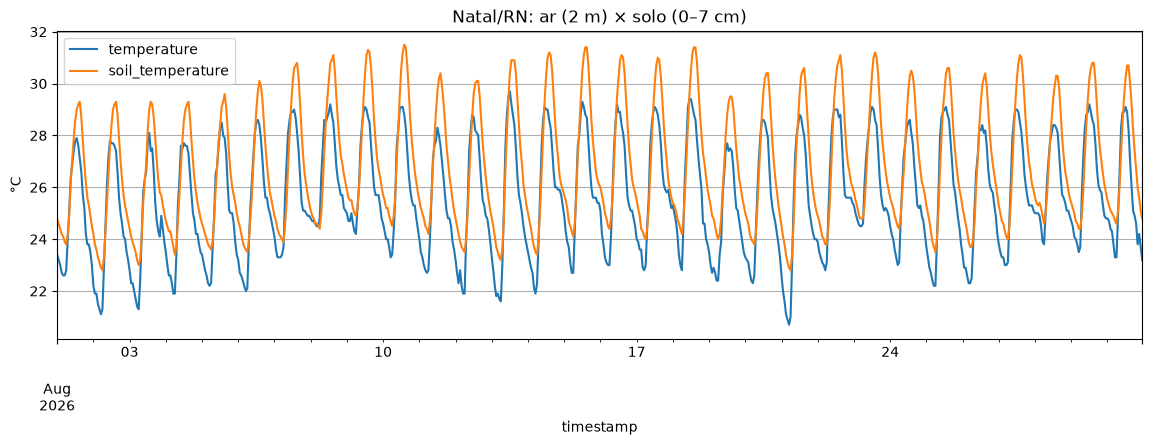

In [4]:
ax = df.plot(x="timestamp", y=["temperature", "soil_temperature"], figsize=(14, 4))
ax.set_ylabel("°C"); ax.set_title("Natal/RN: ar (2 m) × solo (0–7 cm)"); ax.grid()
plt.show()

## 3. Sensor virtual e estado do twin

In [5]:
class VirtualWeatherSensor:
    def __init__(self, dataframe):
        self.data = dataframe.reset_index(drop=True)
        self.index = 0

    def reset(self):
        self.index = 0

    def read(self):
        if self.index >= len(self.data):
            return None
        row = self.data.iloc[self.index]
        self.index += 1
        return {"timestamp": row["timestamp"], **{k: float(row[k]) for k in (
            "temperature", "soil_temperature", "humidity", "pressure", "wind_speed", "solar_radiation")}}


class ClimateDigitalTwin:
    def __init__(self):
        self.state = {}

    def update(self, measurement):
        self.state = measurement

    def show_state(self):
        s = self.state
        print("===== CLIMATE DIGITAL TWIN =====")
        print(f"Timestamp:        {s['timestamp']}")
        print(f"Air temperature:  {s['temperature']:.2f} °C")
        print(f"Soil temperature: {s['soil_temperature']:.2f} °C")
        print(f"Solar radiation:  {s['solar_radiation']:.1f} W/m²")
        print(f"Wind:             {s['wind_speed']:.1f} km/h")


sensor, twin = VirtualWeatherSensor(df), ClimateDigitalTwin()
twin.update(sensor.read())
twin.show_state()

===== CLIMATE DIGITAL TWIN =====
Timestamp:        2026-08-01 00:00:00
Air temperature:  23.40 °C
Soil temperature: 24.80 °C
Solar radiation:  0.0 W/m²
Wind:             14.2 km/h


## 4. A física

Modelo térmico concentrado da camada superficial do solo:

$$C\frac{dT}{dt} = \alpha S(t) - k\,(T - T_{amb}(t))$$

Com $a=\alpha/C$ e $b=k/C$:

$$\frac{dT}{dt} - a\,S(t) + b\,(T - T_{amb}(t)) = 0$$

O PINN aprende $T(t)$, $a$ e $b$. **Quem é quem** decide se a física faz sentido:

| Símbolo | Variável | Por quê |
|---|---|---|
| $T$ | temperatura do **solo** | é o corpo que o sol aquece |
| $T_{amb}$ | temperatura do **ar** | é o ambiente com que o solo troca calor |
| $S$ | radiação solar | a fonte de calor |

> ⚠️ **Armadilha comum:** usar a própria temperatura observada como $T$ **e** como $T_{amb}$. Assim $T - T_{amb} \approx 0$ e $b$ não pode ser identificado: qualquer valor serve.

## 5. Preparar os dados (e três cuidados de normalização)

1. **Tempo** em $[0, 1]$ nos primeiros 7 dias.
2. **$T$ e $T_{amb}$ na mesma escala** (média e desvio do ar). Se cada uma tiver sua própria normalização, $T - T_{amb}$ perde o significado físico.
3. **$S$ dividida pelo máximo**, e não padronizada (z-score). Com z-score, $S$ fica negativa à noite, o que equivale a dizer que "o sol esfria".

In [6]:
DAYS = 7
d = df.iloc[: DAYS * 24].copy().reset_index(drop=True)
d["t"] = np.arange(len(d), dtype=np.float32) / (len(d) - 1)

T_mean, T_std = d["temperature"].mean(), d["temperature"].std()   # uma escala só para T e Tamb
d["T_norm"] = (d["soil_temperature"] - T_mean) / T_std
d["Tamb_norm"] = (d["temperature"] - T_mean) / T_std
d["S_norm"] = d["solar_radiation"] / d["solar_radiation"].max()   # 0 à noite, 1 no pico

d[["timestamp", "t", "soil_temperature", "temperature", "solar_radiation", "S_norm"]].head()

,timestamp,t,soil_temperature,temperature,solar_radiation,S_norm
0,2026-08-01 00:00:00,0.000000,24.8,23.4,0.0,0.0
1,2026-08-01 01:00:00,0.005988,24.6,23.2,0.0,0.0
2,2026-08-01 02:00:00,0.011976,24.4,23.0,0.0,0.0
3,2026-08-01 03:00:00,0.017964,24.2,22.7,0.0,0.0
4,2026-08-01 04:00:00,0.023952,24.1,22.6,0.0,0.0


## 6. O problema físico na API simbólica do PINNeAPPle

Escrevemos a equação como string. Três coisas que a `PINNFactory` entende sozinha:

- **`S(t)` e `Tamb(t)`** não são saídas da rede: são **sinais externos** (dados de sensor). A factory os detecta e pede seus valores no batch.
- **`T0`** não foi declarado: vira uma **constante de execução**, cujo valor passamos no batch.
- **`a` e `b` positivos:** escrevemos `exp(la)` e `exp(lb)`, e a rede aprende `la` e `lb`. Assim o aquecimento solar nunca sai negativo.

In [7]:
from pinneapple_physics.pinn_solver.factory import (
    NeuralNetwork, PINN, PINNFactory, PINNProblemSpec, TabulatedSignal,
)

spec = PINNProblemSpec(
    pde_residuals=["Derivative(T(t), t) - exp(la)*S(t) + exp(lb)*(T(t) - Tamb(t))"],
    conditions=[{"name": "initial_condition", "equation": "T(t) - T0", "weight": 1.0}],
    independent_vars=["t"],
    dependent_vars=["T"],
    inverse_params=["la", "lb"],
    loss_weights={"pde": 1.0, "conditions": 10.0, "data": 10.0},
    verbose=True,
)
factory = PINNFactory(spec)
loss_fn = factory.generate_loss_function()
print("Sinais externos detectados:", factory.exogenous_vars)
print("Constantes de execução:", factory.runtime_constants)

--- PINN Problem Summary ---
  Independent Vars: ['t']
  Dependent Vars: ['T']
  Inverse Params: ['la', 'lb']
  Exogenous Signals (known inputs): ['S', 'Tamb']
  Runtime constants (give values in batch['constants']): ['T0']
  Required Derivatives: {'Derivative(T(t), t)'}
---------------------------
Sinais externos detectados: ['S', 'Tamb']
Constantes de execução: ['T0']


## 7. A rede: features de Fourier do ciclo diário

São 7 dias comprimidos em $t\in[0,1]$, ou seja, 7 oscilações. Uma MLP com `tanh` sobre $t$ puro tem dificuldade com isso (*spectral bias*) e acaba prevendo só a média. Damos à rede o ciclo diário pronto: $[t,\ \sin(2\pi k D t),\ \cos(2\pi k D t)]$, com $D=7$ dias.

In [8]:
class DailyFourier(torch.nn.Module):
    def __init__(self, days, harmonics=3):
        super().__init__()
        self.register_buffer("w", 2 * np.pi * days * torch.arange(1, harmonics + 1, dtype=torch.float32))

    def forward(self, t):
        z = t * self.w
        return torch.cat([t, torch.sin(z), torch.cos(z)], dim=1)


torch.manual_seed(0)
network = torch.nn.Sequential(DailyFourier(DAYS), NeuralNetwork(7, 1, num_layers=3, num_neurons=32, activation=torch.nn.Tanh()))
model = PINN(network, inverse_params_names=["la", "lb"], initial_guesses={"la": 1.0, "lb": 1.0})

## 8. O batch: colocação, condição inicial, dados, sinais externos e constantes

In [9]:
t_obs = torch.tensor(d["t"].values, dtype=torch.float32).reshape(-1, 1)
T_obs = torch.tensor(d["T_norm"].values, dtype=torch.float32).reshape(-1, 1)

batch = {
    "collocation": (torch.linspace(0, 1, 2000).reshape(-1, 1).requires_grad_(True),),
    "conditions": [(torch.zeros(1, 1, requires_grad=True),)],
    "data": ((t_obs,), T_obs),
    # sinais de sensor: interpolados em qualquer ponto de t, de colocação ou de condição
    "exogenous": {
        "S": TabulatedSignal(d["t"].values, d["S_norm"].values),
        "Tamb": TabulatedSignal(d["t"].values, d["Tamb_norm"].values),
    },
    "constants": {"T0": float(d["T_norm"].iloc[0])},
}
total, parts = loss_fn(model, batch)
print(parts)

{'pde': 33.74365234375, 'conditions': 0.11032955348491669, 'data': 1.0304670333862305, 'total': 45.15161895751953}


## 9. Treinamento: Adam e depois SSBroyden

O Adam leva os parâmetros para perto da solução. O **SSBroyden** (quasi-Newton auto-escalado, Urban et al., *J. Comput. Phys.* 2025) faz o refinamento final. É ele que leva $b$ ao valor certo.

In [10]:
from pinneapple_neural.trainer import SelfScaledQuasiNewton

ADAM_EPOCHS, QN_ITERS = 6000, 300
history = []

def params():
    return float(torch.exp(model.inverse_params["la"]).detach()), float(torch.exp(model.inverse_params["lb"]).detach())

optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
for epoch in range(1, ADAM_EPOCHS + 1):
    optimizer.zero_grad()
    loss, parts = loss_fn(model, batch)
    loss.backward()
    optimizer.step()
    history.append([epoch, parts["total"], parts.get("pde", 0), parts.get("data", 0)])
    if epoch == 1 or epoch % 1000 == 0:
        a, b = params()
        print(f"Adam {epoch:5d} | loss={parts['total']:.3e} | física={parts.get('pde', 0):.3e} | dados={parts.get('data', 0):.3e} | a={a:.2f} b={b:.2f}")

qn = SelfScaledQuasiNewton(model.parameters(), variant="ssbroyden", max_iter=QN_ITERS)
def closure():
    qn.zero_grad()
    loss, _ = loss_fn(model, batch)
    loss.backward()
    return loss
qn.step(closure)
parts = loss_fn(model, batch)[1]
a_hat, b_hat = params()
print(f"SSBroyden +{qn.state['n_iter']} it | loss={parts['total']:.3e} | dados={parts.get('data', 0):.3e} | a={a_hat:.2f} b={b_hat:.2f}")

Adam     1 | loss=4.515e+01 | física=3.374e+01 | dados=1.030e+00 | a=2.71 b=2.71


Adam  1000 | loss=8.719e+00 | física=3.367e-01 | dados=8.359e-01 | a=7.98 b=2.24


Adam  2000 | loss=8.487e+00 | física=5.010e-01 | dados=7.977e-01 | a=10.49 b=3.40


Adam  3000 | loss=7.576e+00 | física=1.407e+00 | dados=6.162e-01 | a=22.71 b=9.00


Adam  4000 | loss=4.072e+00 | física=5.410e-01 | dados=3.530e-01 | a=42.21 b=20.68


Adam  5000 | loss=2.580e+00 | física=9.096e-01 | dados=1.671e-01 | a=64.35 b=36.64


Adam  6000 | loss=1.614e+00 | física=3.935e-01 | dados=1.221e-01 | a=72.88 b=45.51


SSBroyden +300 it | loss=1.019e+00 | dados=8.911e-02 | a=90.05 b=63.55


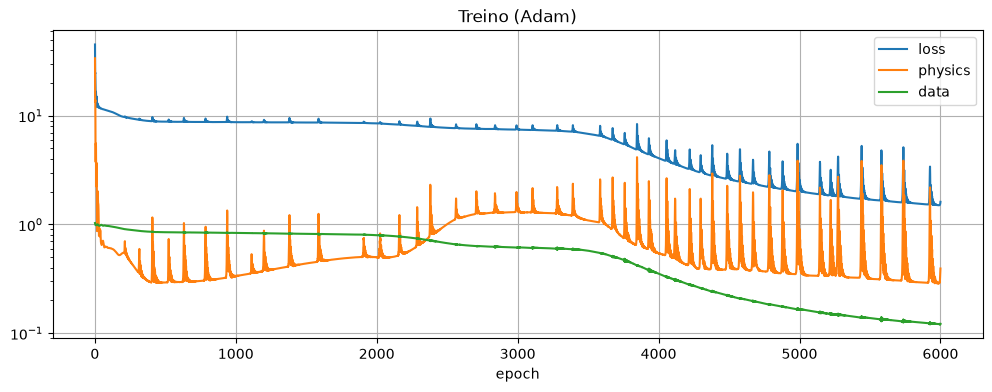

In [11]:
h = pd.DataFrame(history, columns=["epoch", "loss", "physics", "data"])
h.plot(x="epoch", y=["loss", "physics", "data"], logy=True, figsize=(12, 4), title="Treino (Adam)"); plt.grid(); plt.show()

## 10. Parâmetros físicos identificados

Com o tempo normalizado pela janela de 7 dias (168 h), a **constante de tempo** da troca solo↔ar é $\tau = 168/b$ horas.

In [12]:
hours = len(d) - 1
print(f"a (aquecimento solar)   = {a_hat:.2f}")
print(f"b (troca com o ar)      = {b_hat:.2f}")
print(f"constante de tempo τ    = {hours / b_hat:.2f} h")

a (aquecimento solar)   = 90.05
b (troca com o ar)      = 63.55
constante de tempo τ    = 2.63 h


## 11. Validação por dados

MAE  = 0.526 °C
RMSE = 0.641 °C


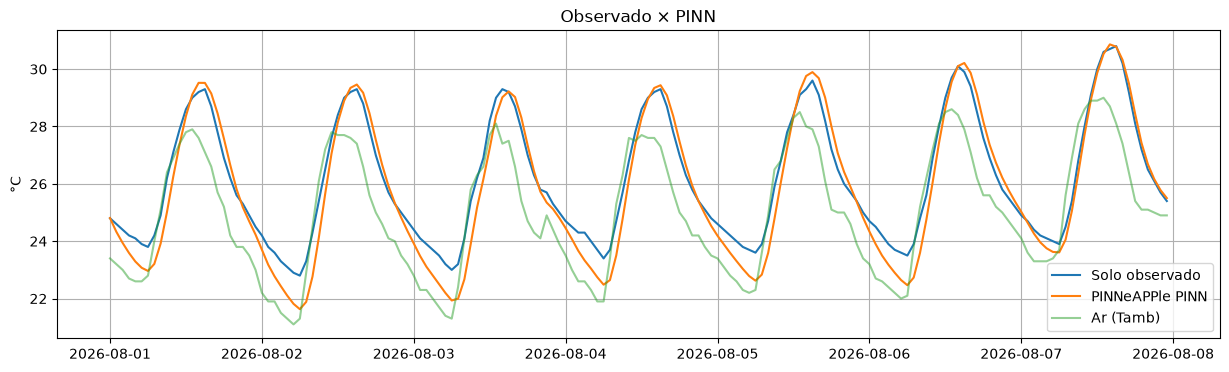

In [13]:
with torch.no_grad():
    d["T_pred"] = model(t_obs).numpy().ravel() * T_std + T_mean
err = d["T_pred"] - d["soil_temperature"]
print(f"MAE  = {err.abs().mean():.3f} °C")
print(f"RMSE = {np.sqrt((err ** 2).mean()):.3f} °C")

plt.figure(figsize=(15, 4))
plt.plot(d["timestamp"], d["soil_temperature"], label="Solo observado")
plt.plot(d["timestamp"], d["T_pred"], label="PINNeAPPle PINN")
plt.plot(d["timestamp"], d["temperature"], label="Ar (Tamb)", alpha=0.5)
plt.ylabel("°C"); plt.legend(); plt.grid(); plt.title("Observado × PINN"); plt.show()

## 12. Validação física

Dois testes que um modelo só de ML não tem:

1. **Resíduo da equação** nos pontos de colocação.
2. **A equação sozinha:** integramos a EDO só com $a$, $b$ e os sinais $S$ e $T_{amb}$, sem a rede, e comparamos com o solo observado. Se $a$ e $b$ são física de verdade, a EDO reproduz a série.

In [14]:
def simulate(S_values, substeps=20):
    T = np.empty(len(d)); T[0] = d["T_norm"].iloc[0]
    dt = 1.0 / hours / substeps
    Ta = d["Tamb_norm"].values
    for i in range(1, len(d)):
        x = T[i - 1]
        for k in range(substeps):
            w = k / substeps
            S_ = (1 - w) * S_values[i - 1] + w * S_values[i]
            A_ = (1 - w) * Ta[i - 1] + w * Ta[i]
            x = x + dt * (a_hat * S_ - b_hat * (x - A_))
        T[i] = x
    return T * T_std + T_mean

t_test = batch["collocation"][0].detach().clone().requires_grad_(True)
T_test = model(t_test)
dT_dt = torch.autograd.grad(T_test, t_test, grad_outputs=torch.ones_like(T_test))[0]
res = dT_dt - a_hat * batch["exogenous"]["S"](t_test) + b_hat * (T_test - batch["exogenous"]["Tamb"](t_test))
print("Resíduo físico (RMSE, unidades normalizadas):", float(torch.sqrt(torch.mean(res.detach() ** 2))))

d["T_ode"] = simulate(d["S_norm"].values)
print(f"EDO só com a, b aprendidos: RMSE = {np.sqrt(((d['T_ode'] - d['soil_temperature']) ** 2).mean()):.3f} °C")

Resíduo físico (RMSE, unidades normalizadas): 0.35731300711631775
EDO só com a, b aprendidos: RMSE = 0.651 °C


## 13. What-If: e se a radiação solar fosse 30% maior?

Como $a$ e $b$ são parâmetros físicos, podemos simular cenários que nunca foram observados.

+30% sol → solo +0.26 °C na média, +0.76 °C no pico


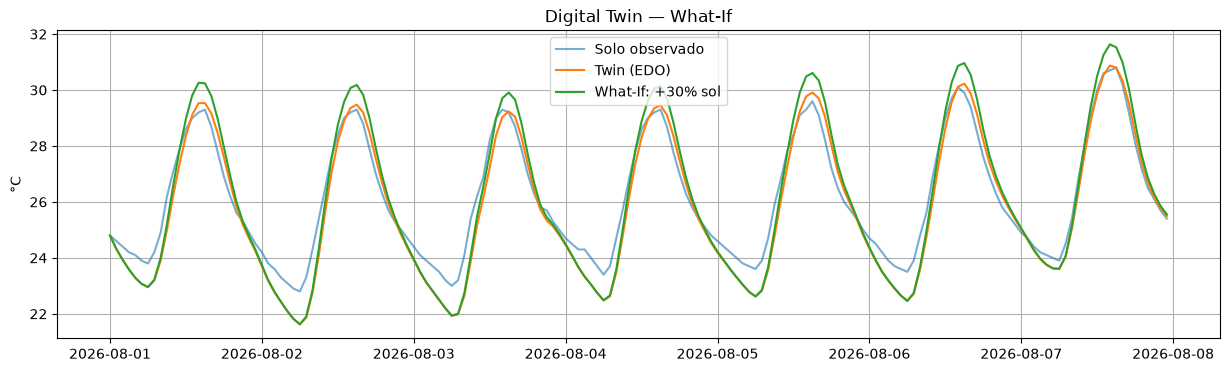

In [15]:
d["T_whatif"] = simulate(d["S_norm"].values * 1.30)
delta = d["T_whatif"] - d["T_ode"]
print(f"+30% sol → solo {delta.mean():+.2f} °C na média, {delta.max():+.2f} °C no pico")

plt.figure(figsize=(15, 4))
plt.plot(d["timestamp"], d["soil_temperature"], label="Solo observado", alpha=0.6)
plt.plot(d["timestamp"], d["T_ode"], label="Twin (EDO)")
plt.plot(d["timestamp"], d["T_whatif"], label="What-If: +30% sol")
plt.ylabel("°C"); plt.legend(); plt.grid(); plt.title("Digital Twin — What-If"); plt.show()

## 14. E se o vento cair 50%?

O modelo **não consegue responder**, porque o vento não aparece na equação. Não devemos fingir que uma variável tem efeito físico se o modelo não representa esse mecanismo.

A evolução natural é pôr o vento na troca de calor por convecção:

$$\frac{dT}{dt} = a\,S - (b_0 + b_1 v)\,(T - T_{amb})$$

Na PINNeAPPle, isso é só mudar a string e passar mais um sinal externo:

```python
spec = PINNProblemSpec(
    pde_residuals=["Derivative(T(t), t) - exp(la)*S(t) + (exp(lb0) + exp(lb1)*v(t))*(T(t) - Tamb(t))"],
    inverse_params=["la", "lb0", "lb1"], ...)
batch["exogenous"]["v"] = TabulatedSignal(d["t"].values, d["wind_speed"].values / d["wind_speed"].max())
```

## Próximos passos

- `pinneapple_systems.digital_twin`: transformar o sensor virtual num `MockStream` e o twin num `DigitalTwin`.
- `pinneapple_twin3d`: visualizar o twin em 3D, com sensores ao vivo.
- Trocar o Open-Meteo por um sensor real (MQTT/OPC-UA).

Fontes: dados do [Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api) (CC BY 4.0). Otimizador: Urban, Stefanou & Pons, *J. Comput. Phys.* 523 (2025), [arXiv:2405.04230](https://arxiv.org/abs/2405.04230).